# 분위수 회귀 (Quantile Regression)
## 지정학적 위기 시 비트코인은 디지털 금인가?
### 캡스톤디자인 | 팀명: 분석많이된다

---

## 분석 목적

주식 시장이 폭락하는 극단적 하락 구간에서 BTC가 반대 방향으로 움직이는지 검증해요.

Safe-Haven의 핵심 조건: **주가가 떨어질 때 BTC는 올라가야** 해요.

## 왜 분위수 회귀인가?

일반 OLS 회귀는 평균적 관계만 봐요. 하지만 안전자산 여부는 **위기 상황(하위 5~10% 극단 구간)**에서만 의미 있어요.

```
OLS     : 전체 수익률 분포의 평균 관계 → 위기 시 반응을 놓침
분위수  : τ=0.05, 0.10 구간만 집중 분석 → 위기 시 반응 포착
```

## 모델

```
Q_τ(BTC_t) = α_τ + β_τ·SP500_t + γ_τ·GPR_custom_t + ε_t

τ = 0.05 : SP500 하위  5% (극단 하락)
τ = 0.10 : SP500 하위 10% (강한 하락)
τ = 0.50 : 중앙값 (평상시 비교용)

Safe-Haven 조건:
  β_τ < 0  (τ=0.05, 0.10에서)  → 주가 폭락 시 BTC는 반대로 움직임
  p < 0.05 → 통계적으로 유의
```

## 필요 파일

```
master_data.csv
```

---
## Step 0. 라이브러리

In [1]:
# !pip install pandas numpy matplotlib scipy statsmodels --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from statsmodels.regression.quantile_regression import QuantReg
from scipy import stats
import warnings, os, platform
warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 130

EVENT_DATES = {
    'hormuz'          : '2019-06-13',
    'soleimani': '2020-01-03',
    'russia_ukraine_war': '2022-02-24',
    'israel_hamas_war'           : '2023-10-07',
    'israel_iran_war'            : '2024-04-01',
    'us_israel_iran_war'         : '2026-02-28',
}
EVENT_LABELS = {
    'hormuz'          : '호르무즈 위기',
    'soleimani': '솔레이마니 암살',
    'russia_ukraine_war': '러-우 전쟁',
    'israel_hamas_war'           : '이스라엘-하마스',
    'israel_iran_war'            : '이스라엘-이란 충돌',
    'us_israel_iran_war'         : '이란 전쟁',
}

# 분석할 분위수
TAUS = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
# Safe-Haven 판단 핵심 분위수
CORE_TAUS = [0.05, 0.10, 0.50]

print('✅ 환경 설정 완료')
print(f'   분석 분위수: {TAUS}')

✅ 환경 설정 완료
   분석 분위수: [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]


---
## Step 1. master_data.csv 로드

In [3]:
if not os.path.exists('master_data.csv'):
    raise FileNotFoundError('master_data.csv 없음')

master = pd.read_csv('master_data.csv')
master['date'] = pd.to_datetime(master['date'])

for col in ['BTC','Gold','TLT','DXY','SP500','NASDAQ',
            'GPR_custom','VIX','fear_greed_lag1']:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors='coerce')

print(f'✅ master_data: {len(master)}행')
print(f'   기간: {master["date"].min().date()} ~ {master["date"].max().date()}')
print(f'\n이벤트별 거래일:')
print(master.groupby('event_name')['date'].count().to_string())
print(f'\n결측치:')
key_cols = ['BTC','SP500','GPR_custom']
print(master[key_cols].isnull().sum().to_string())

✅ master_data: 216행
   기간: 2019-05-20 ~ 2026-03-26

이벤트별 거래일:
event_name
hormuz              34
israel_hamas_war               38
israel_iran_war                37
russia_ukraine_war    35
soleimani    34
us_israel_iran_war             38

결측치:
BTC           0
SP500         0
GPR_custom    0


---
## Step 2. 분석 데이터 준비

전체 이벤트 합산 + 이벤트별 두 가지 방식으로 분석해요.

독립변수(SP500, GPR_custom)는 Z-score 표준화해서 계수 크기를 비교 가능하게 만들어요.

In [4]:
# 전체 이벤트 합산
data_all = master.dropna(subset=['BTC','SP500','GPR_custom']).copy()

# Z-score 표준화 (전체 기준)
for col in ['SP500','GPR_custom','VIX']:
    if col in data_all.columns:
        mu, sig = data_all[col].mean(), data_all[col].std()
        if sig > 0:
            data_all[f'{col}_z'] = (data_all[col] - mu) / sig
        else:
            data_all[f'{col}_z'] = 0

print(f'전체 분석 데이터: {len(data_all)}행')
print(f'\nBTC 수익률 분위수:')
print(data_all['BTC'].quantile([0.05,0.10,0.25,0.50,0.75,0.90,0.95]).round(4))
print(f'\nSP500 수익률 분위수:')
print(data_all['SP500'].quantile([0.05,0.10,0.25,0.50,0.75,0.90,0.95]).round(4))

전체 분석 데이터: 216행

BTC 수익률 분위수:
0.05   -0.0589
0.10   -0.0393
0.25   -0.0175
0.50    0.0013
0.75    0.0227
0.90    0.0575
0.95    0.0887
Name: BTC, dtype: float64

SP500 수익률 분위수:
0.05   -0.0154
0.10   -0.0129
0.25   -0.0057
0.50   -0.0001
0.75    0.0065
0.90    0.0103
0.95    0.0128
Name: SP500, dtype: float64


---
## Step 3. 분위수 회귀 — 전체 이벤트 합산

```
Q_τ(BTC_t) = α_τ + β_τ·SP500_z_t + γ_τ·GPR_custom_z_t
```

τ별로 β(SP500 계수)와 γ(GPR 계수)가 어떻게 달라지는지 확인해요.

In [5]:
from statsmodels.tools import add_constant

def run_quantreg(data, tau, y_col='BTC', x_cols=['SP500_z','GPR_custom_z']):
    """
    분위수 회귀 실행
    Returns: 계수, p-value, 신뢰구간 딕셔너리
    """
    available_x = [c for c in x_cols if c in data.columns]
    df = data[[y_col] + available_x].dropna()
    if len(df) < 15:
        return None

    y = df[y_col].values
    X = add_constant(df[available_x].values)

    try:
        model = QuantReg(y, X)
        res   = model.fit(q=tau, max_iter=2000, p_tol=1e-05)
        return {
            'tau'    : tau,
            'n'      : len(df),
            'params' : res.params,
            'pvalues': res.pvalues,
            'conf_int': res.conf_int(),
            'x_cols' : ['const'] + available_x,
            'result' : res,
        }
    except Exception as e:
        print(f'  ⚠️ τ={tau} 오류: {e}')
        return None


# 전체 이벤트 합산 분석
results_all = {}
print('▶ 분위수 회귀 (전체 이벤트)\n')
print(f'{"τ":>6} {"n":>5} {"α":>10} {"β(SP500)":>12} {"p(β)":>8} '
      f'{"γ(GPR)":>12} {"p(γ)":>8} {"Safe-Haven"}')
print('-' * 85)

for tau in TAUS:
    res = run_quantreg(data_all, tau)
    results_all[tau] = res
    if res is None:
        print(f'{tau:>6.2f}  데이터 부족')
        continue

    params  = res['params']
    pvalues = res['pvalues']
    x_cols  = res['x_cols']

    alpha_i = x_cols.index('const')
    sp_i    = x_cols.index('SP500_z') if 'SP500_z' in x_cols else None
    gpr_i   = x_cols.index('GPR_custom_z') if 'GPR_custom_z' in x_cols else None

    a   = params[alpha_i];   pa = pvalues[alpha_i]
    b   = params[sp_i]  if sp_i  is not None else np.nan
    pb  = pvalues[sp_i] if sp_i  is not None else np.nan
    g   = params[gpr_i] if gpr_i is not None else np.nan
    pg  = pvalues[gpr_i] if gpr_i is not None else np.nan

    # Safe-Haven 판단 (하위 분위에서 β < 0 & 유의)
    if tau <= 0.10:
        if pd.notna(pb) and pb < 0.05 and b < 0:
            sh = '✅ Safe Haven'
        elif pd.notna(pb) and pb < 0.05 and b > 0:
            sh = '❌ Risky Asset'
        elif pd.notna(b) and b < 0:
            sh = '🔵 Weak SH (비유의)'
        else:
            sh = '⚪ 비유의'
    else:
        sh = '—'

    sig_b = '✅' if pd.notna(pb) and pb<0.05 else '—'
    sig_g = '✅' if pd.notna(pg) and pg<0.05 else '—'
    print(f'{tau:>6.2f} {res["n"]:>5} {a:>10.5f} {b:>10.5f}{sig_b:>2} '
          f'{pb:>8.4f} {g:>10.5f}{sig_g:>2} {pg:>8.4f}  {sh}')

▶ 분위수 회귀 (전체 이벤트)

     τ     n          α     β(SP500)     p(β)       γ(GPR)     p(γ) Safe-Haven
-------------------------------------------------------------------------------------
  0.05   216   -0.05333    0.01075 —   0.1996    0.00415 —   0.5616  ⚪ 비유의
  0.10   216   -0.03539    0.00960 ✅   0.0076    0.00569 —   0.0841  ❌ Risky Asset
  0.25   216   -0.01785    0.00767 ✅   0.0067    0.00130 —   0.6363  —
  0.50   216    0.00216    0.00722 ✅   0.0098    0.00436 —   0.1174  —
  0.75   216    0.02359    0.00674 ✅   0.0460    0.01107 ✅   0.0012  —
  0.90   216    0.05637    0.00786 —   0.2587    0.00290 —   0.7173  —
  0.95   216    0.08990    0.01187 —   0.0726   -0.00268 —   0.7342  —


---
## Step 4. 분위수 회귀 — 이벤트별 분석

이벤트별로 τ=0.05, 0.10, 0.50에서 β 계수를 비교해요.

In [6]:
results_event = {}  # results_event[event][tau]

print(f'{"이벤트":<30} {"τ":>6} {"n":>5} {"β(SP500)":>10} {"p(β)":>8} {"γ(GPR)":>10} {"p(γ)":>8} {"판정"}')
print('-' * 95)

for event in EVENT_DATES:
    sub = data_all[data_all['event_name']==event].copy()
    results_event[event] = {}

    for tau in CORE_TAUS:
        res = run_quantreg(sub, tau)
        results_event[event][tau] = res
        if res is None:
            print(f'{event:<30} {tau:>6.2f}  데이터 부족')
            continue

        params  = res['params']
        pvalues = res['pvalues']
        x_cols  = res['x_cols']

        sp_i  = x_cols.index('SP500_z')     if 'SP500_z'     in x_cols else None
        gpr_i = x_cols.index('GPR_custom_z') if 'GPR_custom_z' in x_cols else None

        b  = params[sp_i]   if sp_i  is not None else np.nan
        pb = pvalues[sp_i]  if sp_i  is not None else np.nan
        g  = params[gpr_i]  if gpr_i is not None else np.nan
        pg = pvalues[gpr_i] if gpr_i is not None else np.nan

        if tau <= 0.10:
            if pd.notna(pb) and pb<0.05 and b<0:
                verdict = '✅ Safe Haven'
            elif pd.notna(pb) and pb<0.05 and b>0:
                verdict = '❌ Risky Asset'
            elif pd.notna(b) and b<0:
                verdict = '🔵 Weak SH'
            else:
                verdict = '⚪ 비유의'
        else:
            verdict = '—'

        sig_b = '✅' if pd.notna(pb) and pb<0.05 else '—'
        sig_g = '✅' if pd.notna(pg) and pg<0.05 else '—'
        label = EVENT_LABELS.get(event, event)
        print(f'{label:<30} {tau:>6.2f} {res["n"]:>5} '
              f'{b:>8.5f}{sig_b:>2} {pb:>8.4f} '
              f'{g:>8.5f}{sig_g:>2} {pg:>8.4f}  {verdict}')
    print()

이벤트                                 τ     n   β(SP500)     p(β)     γ(GPR)     p(γ) 판정
-----------------------------------------------------------------------------------------------
호르무즈 위기                          0.05    34 -0.07472 —      nan  0.04540 —      nan  🔵 Weak SH
호르무즈 위기                          0.10    34 -0.08689 —      nan  0.03366 —      nan  🔵 Weak SH
호르무즈 위기                          0.50    34 -0.02265 —   0.1571  0.01549 —   0.2140  —

솔레이마니 암살                         0.05    34 -0.02326 —      nan  0.01034 —      nan  🔵 Weak SH
솔레이마니 암살                         0.10    34 -0.02465 —      nan  0.01007 —      nan  🔵 Weak SH
솔레이마니 암살                         0.50    34 -0.01588 —   0.2000  0.01160 —   0.1080  —

러-우 전쟁                           0.05    35  0.02301 —      nan  0.00460 —      nan  ⚪ 비유의
러-우 전쟁                           0.10    35  0.01932 —      nan -0.01037 —      nan  ⚪ 비유의
러-우 전쟁                           0.50    35  0.01023 —   0.0712  0.00021 —   0.

---
## Step 5. 시각화

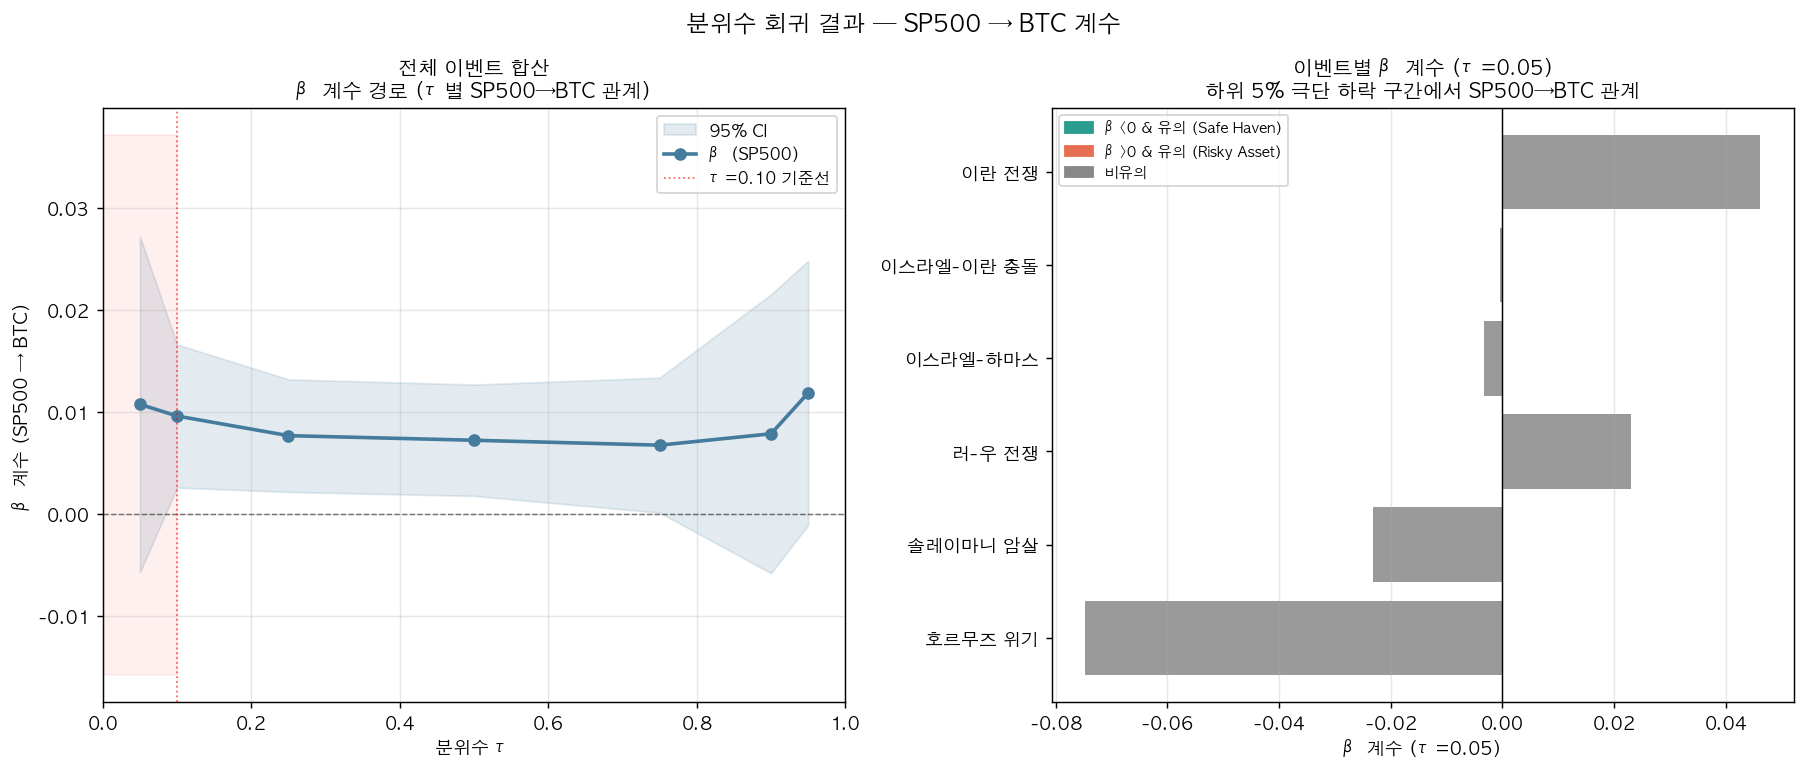

✅ quantreg_beta_path.png 저장


In [7]:
# ── 5-1. β 계수 경로 (Coefficient Plot) ─────────────
# τ가 증가할수록 β가 어떻게 변하는지 → Safe-Haven이면 하위 τ에서 β < 0

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 전체 합산 β 경로
ax = axes[0]
taus_done = [t for t in TAUS if results_all.get(t) is not None]
betas, ci_lo, ci_hi = [], [], []

for tau in taus_done:
    res = results_all[tau]
    x_cols = res['x_cols']
    sp_i   = x_cols.index('SP500_z') if 'SP500_z' in x_cols else None
    if sp_i is not None:
        betas.append(res['params'][sp_i])
        ci_lo.append(res['conf_int'][sp_i, 0])
        ci_hi.append(res['conf_int'][sp_i, 1])
    else:
        betas.append(np.nan)
        ci_lo.append(np.nan)
        ci_hi.append(np.nan)

betas  = np.array(betas)
ci_lo  = np.array(ci_lo)
ci_hi  = np.array(ci_hi)

ax.fill_between(taus_done, ci_lo, ci_hi, alpha=0.15, color='#457B9D', label='95% CI')
ax.plot(taus_done, betas, 'o-', color='#457B9D', lw=2, ms=6, label='β (SP500)')
ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.axvline(0.10, color='red', lw=1, ls=':', alpha=0.6, label='τ=0.10 기준선')
ax.fill_betweenx([min(ci_lo[np.isfinite(ci_lo)])-0.01,
                   max(ci_hi[np.isfinite(ci_hi)])+0.01],
                  0, 0.10, alpha=0.06, color='red')
ax.set_xlabel('분위수 τ')
ax.set_ylabel('β 계수 (SP500 → BTC)')
ax.set_title('전체 이벤트 합산\nβ 계수 경로 (τ별 SP500→BTC 관계)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)

# 이벤트별 τ=0.05 β 비교
ax2 = axes[1]
ev_names, ev_betas, ev_colors = [], [], []
for event in EVENT_DATES:
    res = results_event.get(event, {}).get(0.05)
    if res is None:
        continue
    x_cols = res['x_cols']
    sp_i   = x_cols.index('SP500_z') if 'SP500_z' in x_cols else None
    if sp_i is None:
        continue
    b  = res['params'][sp_i]
    pb = res['pvalues'][sp_i]
    ev_names.append(EVENT_LABELS.get(event, event))
    ev_betas.append(b)
    ev_colors.append('#2A9D8F' if (pb<0.05 and b<0)
                     else '#E76F51' if (pb<0.05 and b>0)
                     else '#888')

bars = ax2.barh(ev_names, ev_betas, color=ev_colors, alpha=0.85)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_xlabel('β 계수 (τ=0.05)')
ax2.set_title('이벤트별 β 계수 (τ=0.05)\n하위 5% 극단 하락 구간에서 SP500→BTC 관계',
               fontsize=11, fontweight='bold')

legend_els = [
    mpatches.Patch(color='#2A9D8F', label='β<0 & 유의 (Safe Haven)'),
    mpatches.Patch(color='#E76F51', label='β>0 & 유의 (Risky Asset)'),
    mpatches.Patch(color='#888',    label='비유의'),
]
ax2.legend(handles=legend_els, fontsize=8)
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('분위수 회귀 결과 — SP500 → BTC 계수', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('quantreg_beta_path.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ quantreg_beta_path.png 저장')

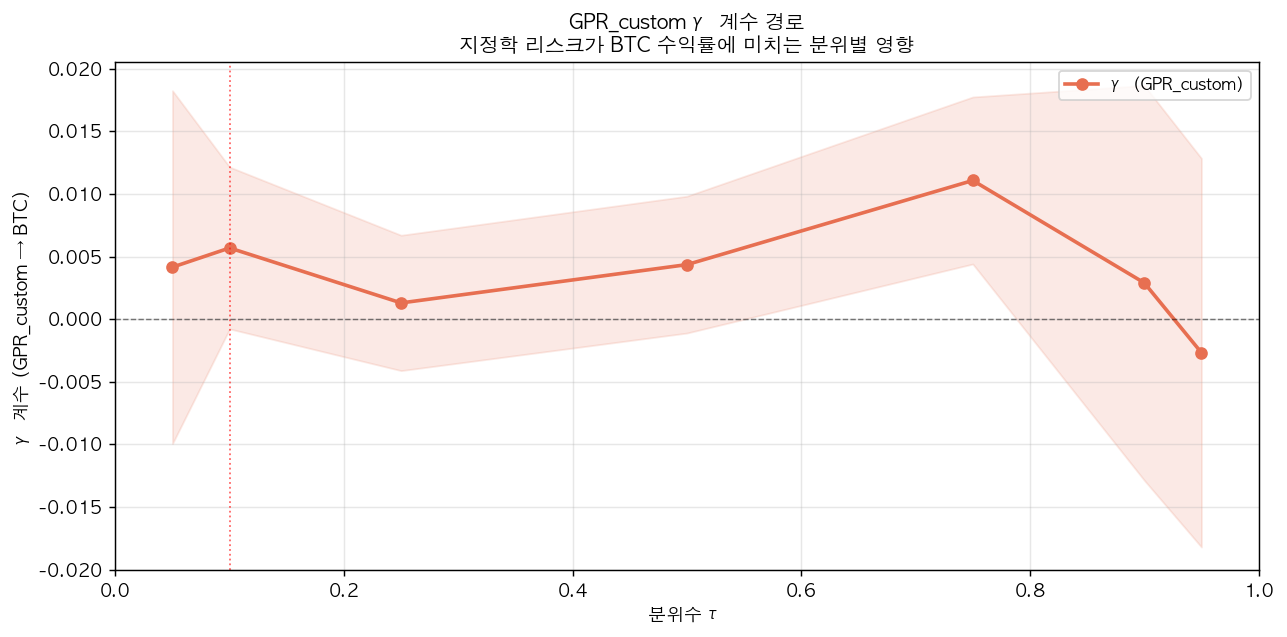

✅ quantreg_gamma_path.png 저장


In [8]:
# ── 5-2. γ 계수 경로 (GPR_custom → BTC) ─────────────
fig, ax = plt.subplots(figsize=(10, 5))

gammas, g_ci_lo, g_ci_hi = [], [], []
for tau in taus_done:
    res    = results_all[tau]
    x_cols = res['x_cols']
    gpr_i  = x_cols.index('GPR_custom_z') if 'GPR_custom_z' in x_cols else None
    if gpr_i is not None:
        gammas.append(res['params'][gpr_i])
        g_ci_lo.append(res['conf_int'][gpr_i, 0])
        g_ci_hi.append(res['conf_int'][gpr_i, 1])
    else:
        gammas.append(np.nan)
        g_ci_lo.append(np.nan)
        g_ci_hi.append(np.nan)

gammas  = np.array(gammas)
g_ci_lo = np.array(g_ci_lo)
g_ci_hi = np.array(g_ci_hi)

ax.fill_between(taus_done, g_ci_lo, g_ci_hi, alpha=0.15, color='#E76F51')
ax.plot(taus_done, gammas, 'o-', color='#E76F51', lw=2, ms=6, label='γ (GPR_custom)')
ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.axvline(0.10, color='red', lw=1, ls=':', alpha=0.6)
ax.set_xlabel('분위수 τ')
ax.set_ylabel('γ 계수 (GPR_custom → BTC)')
ax.set_title('GPR_custom γ 계수 경로\n지정학 리스크가 BTC 수익률에 미치는 분위별 영향',
              fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('quantreg_gamma_path.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ quantreg_gamma_path.png 저장')

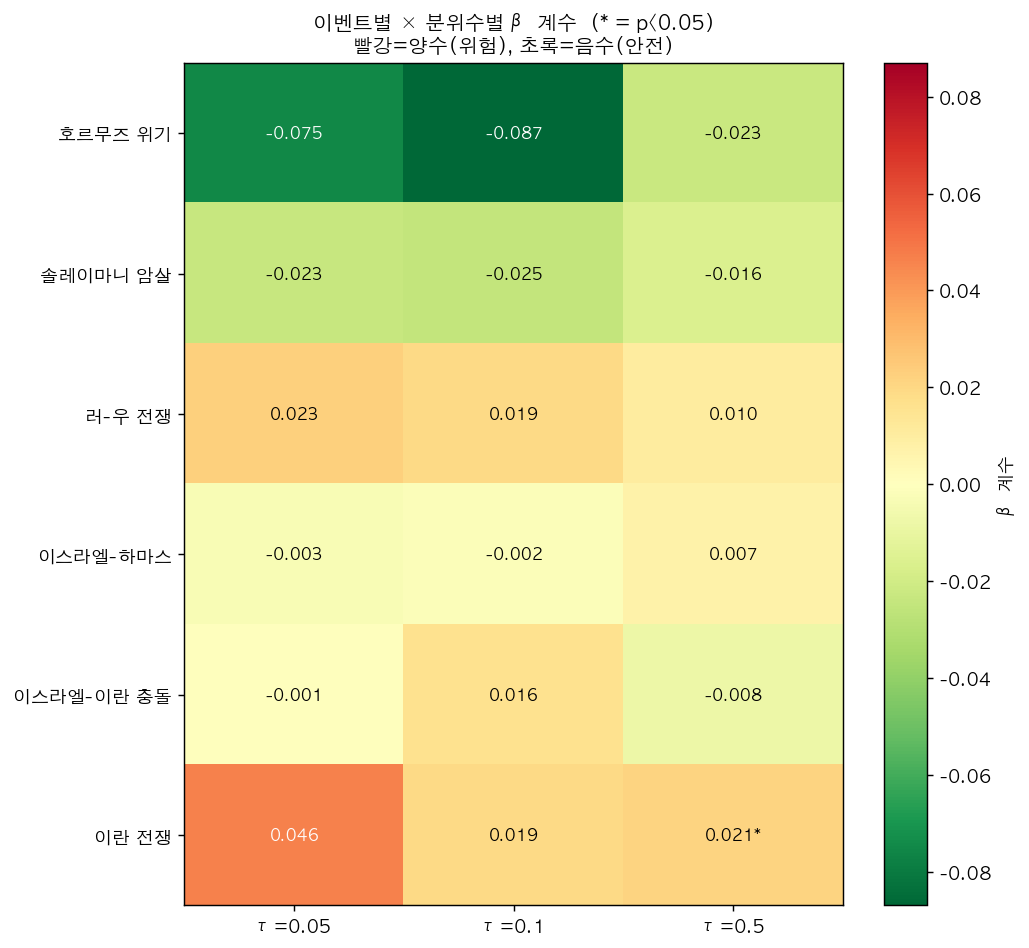

✅ quantreg_heatmap.png 저장


In [9]:
# ── 5-3. 이벤트별 × τ별 히트맵 ──────────────────────
# τ=0.05, 0.10, 0.50에서 이벤트별 β 색깔로 표시

events_list = [ev for ev in EVENT_DATES if results_event.get(ev)]
tau_list    = CORE_TAUS

beta_matrix = np.full((len(events_list), len(tau_list)), np.nan)
sig_matrix  = np.full((len(events_list), len(tau_list)), False)

for i, ev in enumerate(events_list):
    for j, tau in enumerate(tau_list):
        res = results_event.get(ev, {}).get(tau)
        if res is None:
            continue
        x_cols = res['x_cols']
        sp_i   = x_cols.index('SP500_z') if 'SP500_z' in x_cols else None
        if sp_i is not None:
            beta_matrix[i, j] = res['params'][sp_i]
            sig_matrix[i, j]  = res['pvalues'][sp_i] < 0.05

fig, ax = plt.subplots(figsize=(8, max(4, len(events_list)*0.9+2)))
vabs = np.nanmax(np.abs(beta_matrix))
im = ax.imshow(beta_matrix, cmap='RdYlGn_r', vmin=-vabs, vmax=vabs, aspect='auto')
plt.colorbar(im, ax=ax, label='β 계수')

for i in range(len(events_list)):
    for j in range(len(tau_list)):
        val = beta_matrix[i, j]
        txt = f'{val:.3f}' if not np.isnan(val) else 'N/A'
        star = '*' if sig_matrix[i, j] else ''
        color = 'white' if abs(val) > vabs*0.5 and not np.isnan(val) else 'black'
        ax.text(j, i, f'{txt}{star}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_xticks(range(len(tau_list)))
ax.set_xticklabels([f'τ={t}' for t in tau_list])
ax.set_yticks(range(len(events_list)))
ax.set_yticklabels([EVENT_LABELS.get(e,e) for e in events_list])
ax.set_title('이벤트별 × 분위수별 β 계수  (* = p<0.05)\n빨강=양수(위험), 초록=음수(안전)',
              fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('quantreg_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ quantreg_heatmap.png 저장')

---
## Step 6. 최종 판단 — Baur & Lucey (2010)

In [10]:
print('=' * 75)
print('분위수 회귀 Safe-Haven 최종 판단')
print('=' * 75)
print()
print('[전체 이벤트 합산]\n')
print(f'{"τ":>6} {"β(SP500)":>10} {"p(β)":>8} {"유의":>6} {"결론"}')
print('-' * 55)

for tau in CORE_TAUS:
    res = results_all.get(tau)
    if res is None:
        print(f'{tau:>6.2f}  데이터 부족')
        continue
    x_cols = res['x_cols']
    sp_i   = x_cols.index('SP500_z') if 'SP500_z' in x_cols else None
    if sp_i is None:
        continue
    b   = res['params'][sp_i]
    pb  = res['pvalues'][sp_i]
    sig = '✅' if pb < 0.05 else '—'
    if tau <= 0.10:
        if pb<0.05 and b<0:
            verdict = '✅ Safe Haven — 주가 폭락 시 BTC 반대 방향'
        elif pb<0.05 and b>0:
            verdict = '❌ Risky Asset — 주가 폭락 시 BTC도 하락'
        else:
            verdict = '⚪ 비유의 — 통계적으로 불확실'
    else:
        verdict = f'평상시 β={b:.4f}  (비교용)'
    print(f'{tau:>6.2f} {b:>10.5f} {pb:>8.4f} {sig:>6}  {verdict}')

print()
print('[이벤트별 Safe-Haven 판정 요약]\n')
summary_rows = []
for ev in EVENT_DATES:
    row = {'이벤트': EVENT_LABELS.get(ev, ev)}
    for tau in CORE_TAUS:
        res = results_event.get(ev, {}).get(tau)
        if res is None:
            row[f'τ={tau}'] = 'N/A'
            continue
        x_cols = res['x_cols']
        sp_i   = x_cols.index('SP500_z') if 'SP500_z' in x_cols else None
        if sp_i is None:
            row[f'τ={tau}'] = 'N/A'
            continue
        b  = res['params'][sp_i]
        pb = res['pvalues'][sp_i]
        if tau <= 0.10:
            if pb<0.05 and b<0:
                row[f'τ={tau}'] = '✅ SH'
            elif pb<0.05 and b>0:
                row[f'τ={tau}'] = '❌ RA'
            elif b<0:
                row[f'τ={tau}'] = '🔵 Weak'
            else:
                row[f'τ={tau}'] = '⚪'
        else:
            row[f'τ={tau}'] = f'{b:+.4f}'
    summary_rows.append(row)

display(pd.DataFrame(summary_rows).set_index('이벤트'))

분위수 회귀 Safe-Haven 최종 판단

[전체 이벤트 합산]

     τ   β(SP500)     p(β)     유의 결론
-------------------------------------------------------
  0.05    0.01075   0.1996      —  ⚪ 비유의 — 통계적으로 불확실
  0.10    0.00960   0.0076      ✅  ❌ Risky Asset — 주가 폭락 시 BTC도 하락
  0.50    0.00722   0.0098      ✅  평상시 β=0.0072  (비교용)

[이벤트별 Safe-Haven 판정 요약]



,τ=0.05,τ=0.1,τ=0.5
이벤트,,,
호르무즈 위기,🔵 Weak,🔵 Weak,-0.0226
솔레이마니 암살,🔵 Weak,🔵 Weak,-0.0159
러-우 전쟁,⚪,⚪,+0.0102
이스라엘-하마스,🔵 Weak,🔵 Weak,+0.0071
이스라엘-이란 충돌,🔵 Weak,⚪,-0.0076
이란 전쟁,⚪,⚪,+0.0211


---
## Step 7. 결과 저장

In [11]:
# 전체 결과 테이블
all_rows = []
for tau in TAUS:
    res = results_all.get(tau)
    if res is None:
        continue
    x_cols  = res['x_cols']
    sp_i    = x_cols.index('SP500_z')     if 'SP500_z'     in x_cols else None
    gpr_i   = x_cols.index('GPR_custom_z') if 'GPR_custom_z' in x_cols else None
    const_i = x_cols.index('const')
    all_rows.append({
        'scope' : '전체',
        'event' : 'all',
        'tau'   : tau,
        'n'     : res['n'],
        'alpha' : round(res['params'][const_i], 6),
        'beta_sp500'  : round(res['params'][sp_i],  6) if sp_i  is not None else np.nan,
        'p_beta'      : round(res['pvalues'][sp_i], 4) if sp_i  is not None else np.nan,
        'gamma_gpr'   : round(res['params'][gpr_i], 6) if gpr_i is not None else np.nan,
        'p_gamma'     : round(res['pvalues'][gpr_i],4) if gpr_i is not None else np.nan,
    })

for ev in EVENT_DATES:
    for tau in CORE_TAUS:
        res = results_event.get(ev, {}).get(tau)
        if res is None:
            continue
        x_cols  = res['x_cols']
        sp_i    = x_cols.index('SP500_z')     if 'SP500_z'     in x_cols else None
        gpr_i   = x_cols.index('GPR_custom_z') if 'GPR_custom_z' in x_cols else None
        const_i = x_cols.index('const')
        all_rows.append({
            'scope' : '이벤트별',
            'event' : ev,
            'tau'   : tau,
            'n'     : res['n'],
            'alpha' : round(res['params'][const_i], 6),
            'beta_sp500'  : round(res['params'][sp_i],  6) if sp_i  is not None else np.nan,
            'p_beta'      : round(res['pvalues'][sp_i], 4) if sp_i  is not None else np.nan,
            'gamma_gpr'   : round(res['params'][gpr_i], 6) if gpr_i is not None else np.nan,
            'p_gamma'     : round(res['pvalues'][gpr_i],4) if gpr_i is not None else np.nan,
        })

result_df = pd.DataFrame(all_rows)
result_df.to_csv('quantreg_results.csv', index=False, encoding='utf-8-sig')

print('▶ 최종 산출물:')
for f in ['quantreg_results.csv',
          'quantreg_beta_path.png',
          'quantreg_gamma_path.png',
          'quantreg_heatmap.png']:
    flag = '✅' if os.path.exists(f) else '📄 (실행 후 생성)'
    print(f'  {flag} {f}')

▶ 최종 산출물:
  ✅ quantreg_results.csv
  ✅ quantreg_beta_path.png
  ✅ quantreg_gamma_path.png
  ✅ quantreg_heatmap.png
